# Immune integration: ATAC tile loading

Load ATAC fragment files for all 99 samples, create 1kb tile count matrix using SnapATAC2/cell2state.

**Environment**: `cell2state_v2026_cuda124_torch25` (NOT regularizedvi)
**Input**: `results/immune_integration/adata_rna.h5ad` (for cell barcodes + fragment_file_path)
**Output**: `results/immune_integration/adata_atac_tiles.h5ad`

In [1]:
import scanpy as sc
import numpy as np
import os

## Load RNA metadata

In [2]:
data_folder = "results/immune_integration/"
rna_path = os.path.join(data_folder, "adata_rna.h5ad")

adata = sc.read_h5ad(rna_path)
print(f"RNA adata: {adata.shape}")
print(f"Batches: {adata.obs['batch'].nunique()}")
print(f"fragment_file_path column: {'fragment_file_path' in adata.obs.columns}")

# Check all fragment file paths exist
if "fragment_file_path" in adata.obs.columns:
    paths = adata.obs["fragment_file_path"].unique()
    missing = [p for p in paths if not os.path.exists(p)]
    print(f"\nFragment files: {len(paths)} unique paths")
    if missing:
        print(f"WARNING: {len(missing)} missing files:")
        for p in missing[:5]:
            print(f"  {p}")
    else:
        print("All fragment files exist")

RNA adata: (706322, 25629)
Batches: 92
fragment_file_path column: True



Fragment files: 92 unique paths
All fragment files exist


## Verify barcode format

obs_names are now in `{batch}-{barcode}` cell2state format directly from data loading. No renaming needed.

In [3]:
# Verify obs_names are in {batch}-{barcode} format (no renaming needed)
assert all("-" in n for n in adata.obs_names[:100]), "obs_names not in {batch}-{barcode} format"
print(f"obs_names format OK. Examples: {list(adata.obs_names[:3])}")

obs_names format OK. Examples: ['s1d1-TAGTTGTCACCCTCAC-1', 's1d1-CTATGGCCATAACGGG-1', 's1d1-CCGCACACAGGTTAAA-1']


## Check SnapATAC2 cached files

In [4]:
# Check cached h5ad files next to fragment files
cached_files = []
missing_cache = []

for path in sorted(adata.obs["fragment_file_path"].unique()):
    h5ad_cache = path.replace(".tsv.gz", ".h5ad")
    if os.path.exists(h5ad_cache):
        cached_files.append(h5ad_cache)
    else:
        missing_cache.append(path)

print(f"Cached h5ad files: {len(cached_files)}/{len(cached_files) + len(missing_cache)}")
if missing_cache:
    print(f"\nMissing cache for {len(missing_cache)} samples:")
    for p in missing_cache[:5]:
        print(f"  {p}")

Cached h5ad files: 92/92


## Load ATAC tiles

In [5]:
# Papermill parameters
genome_ref = "/nfs/srpipe_references/downloaded_from_10X/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/"
max_frag_size_split = 160
bin_size = 1000
counting_strategy = "insertion"
results_folder = "results/immune_integration/"

In [6]:
from cell2state.utils.aggregation_v2 import concatenate_h5ad

adata_atac = concatenate_h5ad(
    adata,
    variable_type="atac_tiles",
    batch_key="batch",
    loading_kwargs={
        "path_to_reference": genome_ref,
        "path_to_fragment_file_key": "fragment_file_path",
        "max_frag_size_split": max_frag_size_split,
        "bin_size": bin_size,
        "counting_strategy": counting_strategy,
        "use_complete_path": True,
    },
)

print(f"Concatenated ATAC tiles: {adata_atac.shape}")
print(f"dtype: {adata_atac.X.dtype}")

/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWar

/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)


/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing CSRDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSRDataset instead.
  warnings.warn(msg, FutureWarning)


/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/software/conda/users/vk7/cell2state_v2026_cuda124_torch25/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing CSRDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSRDataset instead.
  warnings.warn(msg, FutureWarning)


...

INFO     cell2state: Loading fragment counts (<160) for sample PDC149                                              


INFO     cell2state: Loading fragment counts (>160) for sample PDC149                                              


Working...: 100%|██████████| 92/92 [8:15:26<00:00, 313.04s/it]

Working...: 100%|██████████| 92/92 [8:15:26<00:00, 323.11s/it]

Concatenated ATAC tiles: (690590, 3042603)
dtype: uint32


## Post-processing

In [7]:
# Ensure sparse uint32 for processing (uint16 cast happens before saving)
import scipy.sparse as sp

if not sp.issparse(adata_atac.X):
    adata_atac.X = sp.csr_matrix(adata_atac.X, dtype=np.uint32)
elif adata_atac.X.dtype != np.uint32:
    print(f"Casting dtype from {adata_atac.X.dtype} to uint32")
    adata_atac.X = adata_atac.X.astype(np.uint32)

# Store counts layer
adata_atac.layers["counts"] = adata_atac.X.copy()

print(f"Final shape: {adata_atac.shape}")
print(f"dtype: {adata_atac.X.dtype}")
print(f"Memory: {adata_atac.X.data.nbytes / 1e9:.1f} GB")

Final shape: (690590, 3042603)
dtype: uint32
Memory: 15.4 GB


Total fragments: median=7022, range=[74, 1378082]
Tiles accessible: median=4236, range=[47, 678714]


Saved ATAC QC metrics: results/immune_integration/atac_qc_metrics.csv


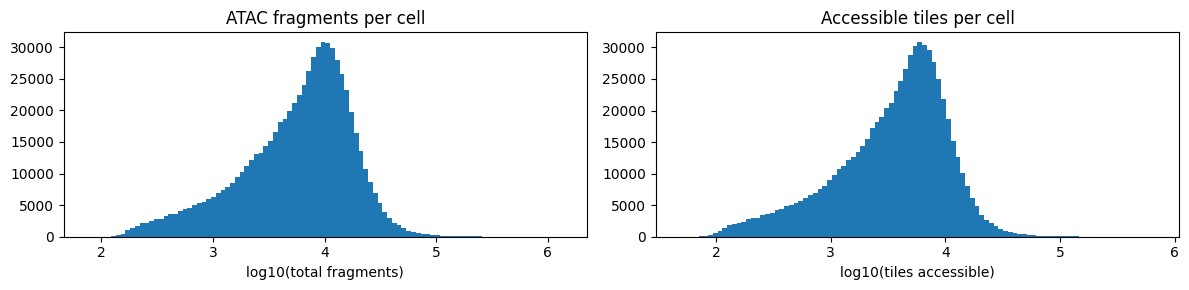

In [8]:
import matplotlib.pyplot as plt

# ATAC QC metrics
total_frags = np.array(adata_atac.X.sum(1)).squeeze()
n_tiles = np.array((adata_atac.X > 0).sum(1)).squeeze()

adata_atac.obs["total_fragments"] = total_frags
adata_atac.obs["n_tiles_accessible"] = n_tiles

print(f"Total fragments: median={np.median(total_frags):.0f}, range=[{total_frags.min()}, {total_frags.max()}]")
print(f"Tiles accessible: median={np.median(n_tiles):.0f}, range=[{n_tiles.min()}, {n_tiles.max()}]")

# Save ATAC QC metrics as CSV (for use by RNA training notebook)
atac_qc_df = adata_atac.obs[["total_fragments", "n_tiles_accessible"]].copy()
atac_qc_df.to_csv(os.path.join(results_folder, "atac_qc_metrics.csv"))
print(f"Saved ATAC QC metrics: {os.path.join(results_folder, 'atac_qc_metrics.csv')}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(np.log10(total_frags + 1), bins=100)
axes[0].set_xlabel("log10(total fragments)")
axes[0].set_title("ATAC fragments per cell")
axes[1].hist(np.log10(n_tiles + 1), bins=100)
axes[1].set_xlabel("log10(tiles accessible)")
axes[1].set_title("Accessible tiles per cell")
plt.tight_layout()
plt.show()

## Save

In [9]:
# Convert to uint16 before saving (QC/processing done on uint32)
adata_atac.X = adata_atac.X.tocsr().astype(np.uint16)
adata_atac.layers["counts"] = adata_atac.X.copy()
print(f"Save dtype: {adata_atac.X.dtype}")

output_path = os.path.join(results_folder, "adata_atac_tiles.h5ad")
adata_atac.write_h5ad(output_path)
print(f"Saved to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1e9:.1f} GB")

Save dtype: uint16


... storing 'sample' as categorical


Saved to results/immune_integration/adata_atac_tiles.h5ad
File size: 165.1 GB
